# AI for Transportation | Recitation 2: Discrete Choice Modeling

In this recitation, we study **Discrete Choice Modeling (DCM)** using both classical baselines and a modern, theory-informed neural network approach: the **Alternative-Specific Utility Deep Neural Network (ASU-DNN)** as presented during lecture and in [this paper by ](https://doi.org/10.1016/j.trc.2020.01.012). Our goal is to understand how a utility-theoretic structure can guide neural architectures to achieve **better prediction**, **clearer interpretation**, and **stronger generalization** than a simple logistic baseline, a multinomial logit model, and a fully connected DNN architecture.

We will work with the [1987 Netherlands **Train**](https://open.rijkswaterstaat.nl/@120703/the-netherlands-value-time-study-final/) mode-choice dataset which is distributed by the [**mlogit**](https://cran.r-project.org/web/packages/mlogit/index.html) R package. You can find information on the dataset in the mlogit [documentation](https://www.rdocumentation.org/packages/mlogit/versions/0.2-4/topics/Train) as well as [this document](https://drive.google.com/file/d/17BR1nNP3Cjca3_YjA3aH_BD-e-ov1z83/view?usp=drive_link), which is the original report explaining the data sampling process.

We will proceed in four parts:

1. **Data Access & Preparation**  
   - Import the `Train` dataset and convert it to long/choice-format using `pandas`.  
   - Define a k-fold cross validation data split into train/test sets with traveler-level grouping.

2. **Classical Baselines (Utility Models)**  
   - Fit a **Regression** model
   - Fit **Multinomial Logit (MNL)** with alternative-specific constants and key attributes (time, cost, etc.).  
   - Report **in-sample fit** and **out-of-sample accuracy**.  
   - Extract **elasticities**, **value of time (VOT)**, and **substitution patterns** for interpretability.

3. **ASU-DNN (Theory-Guided Architecture)**  
   - Build a sparse, **alternative-specific** network where each alternative's attributes feed only its own utility head (softmax over utilities).  
   - Train with cross-entropy; compare against a **Fully Connected (FC) DNN** of similar capacity.  
   - Evaluate **accuracy**, **calibration**, and **interpretability** (e.g., cost/time response curves per mode).

4. **Comparison & Reflection**  
   - Side-by-side results for **MNL vs. FC-DNN vs. ASU-DNN**.  
   - Discuss the trade-off between **approximation power** and **estimation stability**, and how ASU-DNN acts as a **domain-knowledge regularizer**.  

By the end, you will:
- Load and prepare a **choice-format** dataset
- Fit and interpret a **classical MNL** model.  
- Implement and train a **theory-informed ASU-DNN**, and compare it with a **FC-DNN**.
- Analyze the results

In [39]:
# Imports

import os
import warnings
from dataclasses import dataclass
from typing import Tuple, List, Optional

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.special import logsumexp

import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, callbacks

from sklearn.model_selection import StratifiedKFold, KFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, log_loss, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Reproducibility & Plotting
RANDOM_STATE = 100
np.random.seed(RANDOM_STATE)
sns.set(context="notebook", style="whitegrid")

# Device Selection
device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using device: {device}")

Using device: /CPU:0


If you see "Using device: /CPU:0", we **recommend switching your runtime to use a T4 GPU**. Google Colab offers these for free up to a certain monthly limit. For setup guidance, see the [Colab GPU documentation](https://cloud.google.com/colab/docs/default-runtimes-with-gpus#enable).

## Data Loading

In [40]:
!gdown 1n_thf9fWac4cpgmp2VjCjB8Z98H4zbrs

Downloading...
From: https://drive.google.com/uc?id=1n_thf9fWac4cpgmp2VjCjB8Z98H4zbrs
To: /content/mlogit_Train_wide.csv
100% 122k/122k [00:00<00:00, 72.4MB/s]


We'll load the 1987 Netherlands Train choice dataset, which contains a sample of 235 Dutch individuals facing 2929 choice situations. The underlying choices are binary between two transportation alternatives.

In [41]:
df_raw = pd.read_csv('mlogit_Train_wide.csv')

# Display basic info about the dataset
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)

# First, let's see what columns we actually have
print(f"Dataset shape: {df_raw.shape[0]:,} observations × {df_raw.shape[1]} variables")

display(df_raw.head(8))

# Use the actual column names from the dataset
id_col = df_raw.columns[0] if len(df_raw.columns) > 0 else None
choice_col = 'choice' if 'choice' in df_raw.columns else df_raw.columns[2] if len(df_raw.columns) > 2 else None

print(f"\nVariable Summary:")
print(f"- Individual identifiers: {df_raw[id_col].nunique():,} unique individuals")
per_person = df_raw.groupby('id')['choiceid'].nunique()
print(f"- Avg scenarios per individual: {per_person.mean():.2f} "
      f"(median {per_person.median()}, min {per_person.min()}, max {per_person.max()})")
print(f"- Total choice observations: {len(df_raw):,}")

# Check the choice distribution
choice_dist = df_raw[choice_col].value_counts()
print(f"\n Choice Distribution:")
for choice, count in choice_dist.items():
    percentage = (count / len(df_raw)) * 100
    print(f"- {choice}: {count:,} ({percentage:.1f}%)")


DATASET OVERVIEW
Dataset shape: 2,929 observations × 11 variables


,id,choiceid,choice,price1,time1,change1,comfort1,price2,time2,change2,comfort2
0,1,1,choice1,2400,150,0,1,4000,150,0,1
1,1,2,choice1,2400,150,0,1,3200,130,0,1
2,1,3,choice1,2400,115,0,1,4000,115,0,0
3,1,4,choice2,4000,130,0,1,3200,150,0,0
4,1,5,choice2,2400,150,0,1,3200,150,0,0
5,1,6,choice2,4000,115,0,0,2400,130,0,0
6,1,7,choice2,2400,150,0,1,3200,115,0,1
7,1,8,choice2,2400,115,0,1,3200,150,0,0



Variable Summary:
- Individual identifiers: 235 unique individuals
- Avg scenarios per individual: 12.46 (median 13.0, min 5, max 19)
- Total choice observations: 2,929

 Choice Distribution:
- choice1: 1,474 (50.3%)
- choice2: 1,455 (49.7%)


### Variable Overview

| Variable   | Description                                                                 |
|------------|-----------------------------------------------------------------------------|
| id         | individual identifier                                                       |
| choiceid   | choice identifier                                                           |
| choice     | one of choice1, choice2                                                     |
| pricez     | price of proposition z (z = 1, 2) in cents of guilders                      |
| timez      | travel time of proposition z (z = 1, 2) in minutes                          |
| comfortz   | comfort of proposition z (z = 1, 2), values 0, 1, or 2 (decreasing comfort) |
| changez    | number of changes for proposition z (z = 1, 2)                              |

### Basic statistics
The dataset has **no missing values** and here are some statistics:

*Comfort Level Distribution:* (0 = highest comfort, 2 = lowest comfort)
- Alternative 1 comfort levels:
    - Level 0 (High): **693 (23.7%)**
    - Level 1 (Medium): **1,839 (62.8%)**
    - Level 2 (Low): **397 (13.6%)**
- Alternative 2 comfort levels:
    - Level 0 (High): **743 (25.4%)**
    - Level 1 (Medium): **1,780 (60.8%)**
    - Level 2 (Low): **406 (13.9%)**

*Choice Structure Analysis:*
- Total observations: **2,929**
- Unique choice scenarios (choiceid): **19**
- Average scenarios per individual: **154.2**
- Choice scenarios range: **1 to 234 per individual**
- Most individuals have: **233 choice scenarios**

### Wide to long format transformation

In [ ]:


def transform_wide_to_long(df_wide):
    """
    Transform wide-format choice data to long-format for discrete choice modeling.

    Parameters
    ----------
    df_wide : pd.DataFrame
        Wide format data with choice1/choice2 alternatives in columns

    Returns
    -------
    pd.DataFrame
        Long format data with one row per alternative
    """
    long_data = []
    for obs_id, row in df_wide.iterrows():
        for alt in [1, 2]:
            alt_label = f"choice{alt}"
            long_data.append({
                "id": row["id"],            # individual identifier
                "obs_id": obs_id,           # one choice situation per wide row
                "choiceid": row["choiceid"],# scenario index within person
                "alternative": alt,
                "chosen": int(row["choice"] == alt_label),
                "price": row[f"price{alt}"],
                "time": row[f"time{alt}"],
                "comfort": row[f"comfort{alt}"],
                "change": row[f"change{alt}"],
            })
    return pd.DataFrame(long_data)

In [42]:
# Data Transformation: Wide to Long Format

df_long = transform_wide_to_long(df_raw)

print(f"Original wide format: {len(df_raw):,} choice scenarios")
print(f"New long format: {len(df_long):,} alternative observations")

# Show the long format structure
print(f"\nLong Format Structure (first 6 rows):")
display(df_long.head(6))

# Verify choice indicators sum correctly
total_choices = df_long['chosen'].sum()
expected_choices = len(df_raw)  # One choice per scenario
print(f"\nChoice verification: {total_choices:,} total choices = {expected_choices:,} scenarios")

# Show distribution of choices by alternative
alt_choices = df_long.groupby('alternative')['chosen'].sum()
print(f"\nChoices by Alternative:")
for alt, count in alt_choices.items():
    percentage = (count / total_choices) * 100
    print(f"- Alternative {alt}: {count:,} choices ({percentage:.1f}%)")

# Calculate some preliminary insights
print(f"\nPreliminary Insights:")
chosen_alts = df_long[df_long['chosen'] == 1]

print(f"- Average price of chosen alternatives: {chosen_alts['price'].mean():.0f} cents")
print(f"- Average time of chosen alternatives: {chosen_alts['time'].mean():.1f} minutes")

# Compare chosen vs not chosen
not_chosen = df_long[df_long['chosen'] == 0]
print(f"\nChosen vs Not Chosen Comparison:")
print(f"- Price difference (chosen - not chosen): {chosen_alts['price'].mean() - not_chosen['price'].mean():.0f} cents")
print(f"- Time difference (chosen - not chosen): {chosen_alts['time'].mean() - not_chosen['time'].mean():.1f} minutes")
print(f"- Comfort difference (chosen - not chosen): {chosen_alts['comfort'].mean() - not_chosen['comfort'].mean():.2f} levels")

Original wide format: 2,929 choice scenarios
New long format: 5,858 alternative observations

Long Format Structure (first 6 rows):


,id,obs_id,choiceid,alternative,chosen,price,time,comfort,change
0,1,0,1,1,1,2400,150,1,0
1,1,0,1,2,0,4000,150,1,0
2,1,1,2,1,1,2400,150,1,0
3,1,1,2,2,0,3200,130,1,0
4,1,2,3,1,1,2400,115,1,0
5,1,2,3,2,0,4000,115,0,0



Choice verification: 2,929 total choices = 2,929 scenarios

Choices by Alternative:
- Alternative 1: 1,474 choices (50.3%)
- Alternative 2: 1,455 choices (49.7%)

Preliminary Insights:
- Average price of chosen alternatives: 3235 cents
- Average time of chosen alternatives: 127.2 minutes

Chosen vs Not Chosen Comparison:
- Price difference (chosen - not chosen): -265 cents
- Time difference (chosen - not chosen): -0.3 minutes
- Comfort difference (chosen - not chosen): -0.10 levels


### Exploratory Data Analysis & Visualization
Let's dive deeper into the choice patterns and understand the relationships between attributes and choices through comprehensive visualizations.

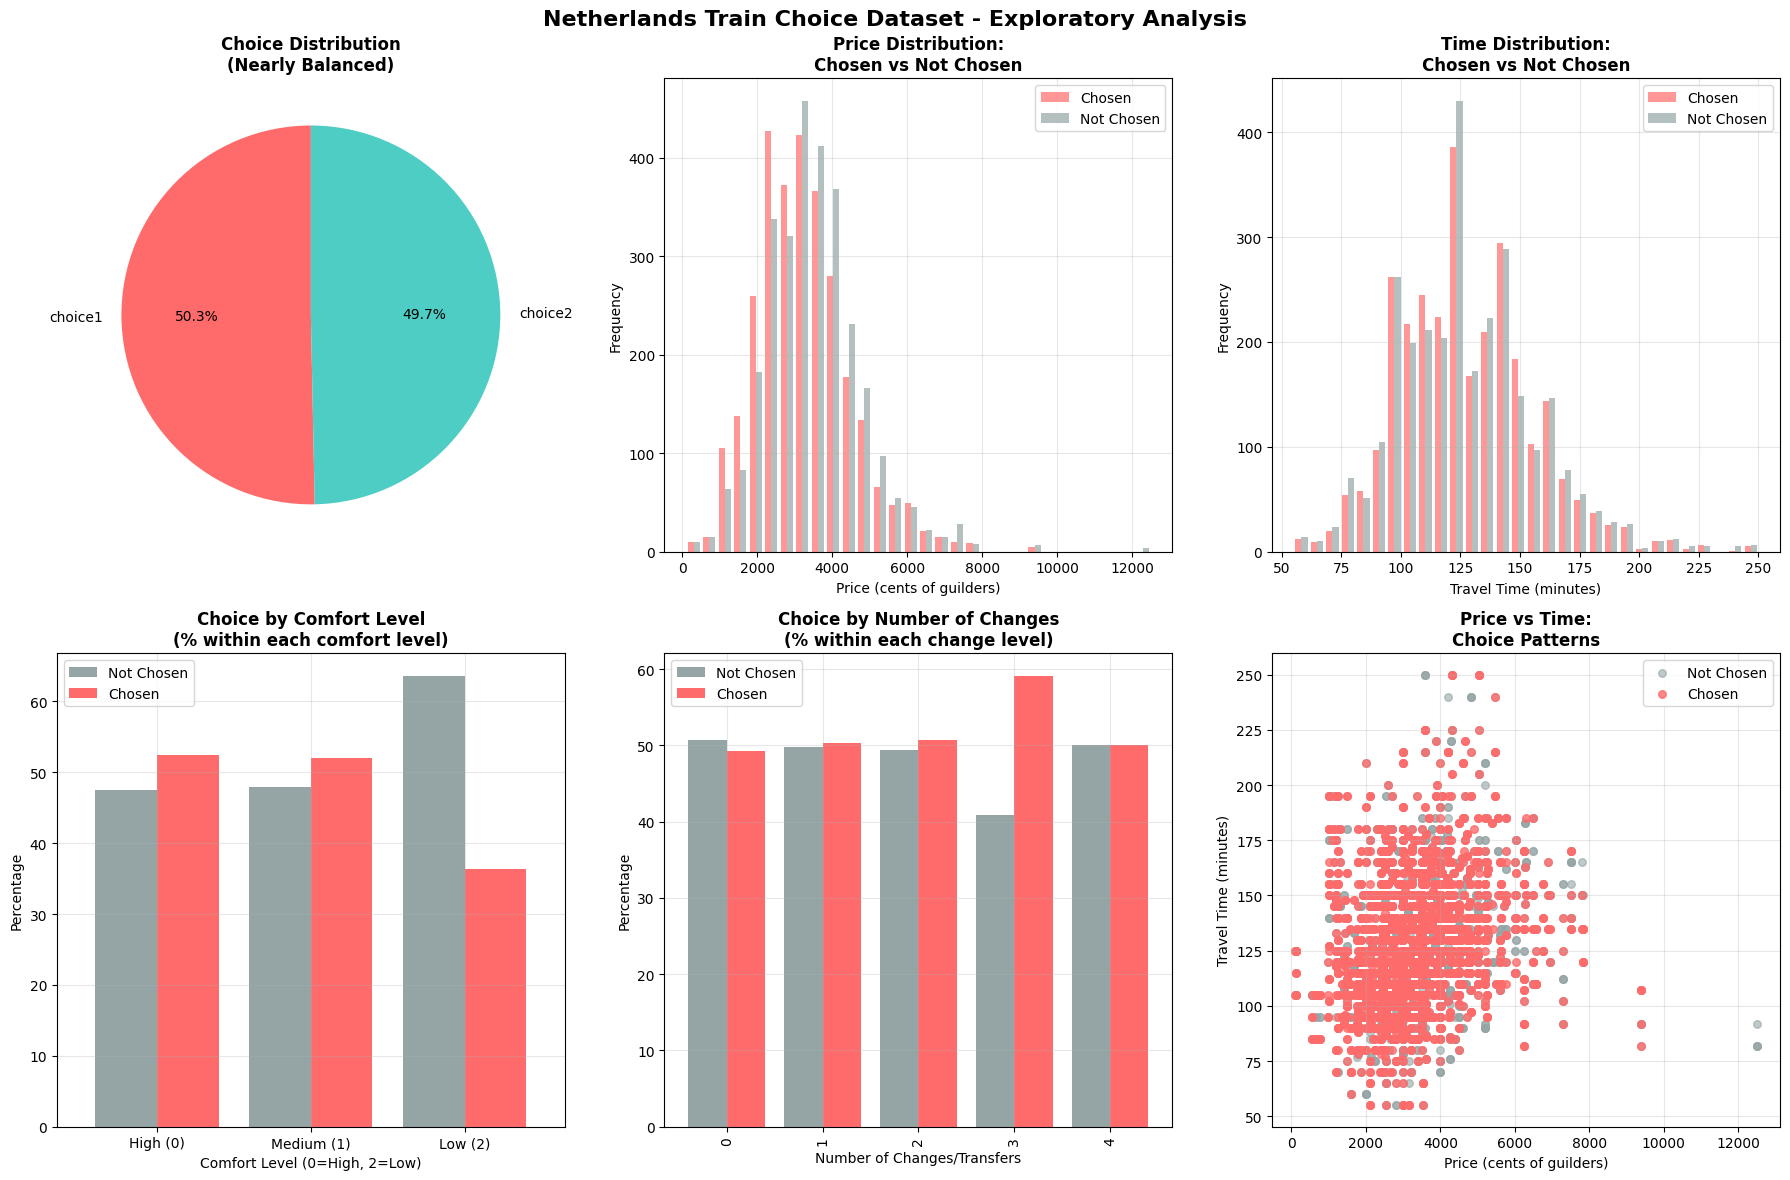

In [43]:
# Set up the plotting style for better visualizations
plt.style.use('default')
sns.set_palette("husl")
fig_count = 0

# Create subplots for comprehensive analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Netherlands Train Choice Dataset - Exploratory Analysis', fontsize=16, fontweight='bold')

# 1. Choice Distribution
ax1 = axes[0, 0]
choice_counts = df_raw['choice'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = ax1.pie(choice_counts.values, labels=choice_counts.index,
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Choice Distribution\n(Nearly Balanced)', fontweight='bold')

# 2. Price Distribution by Choice
ax2 = axes[0, 1]
chosen_prices = df_long[df_long['chosen'] == 1]['price']
not_chosen_prices = df_long[df_long['chosen'] == 0]['price']

ax2.hist([chosen_prices, not_chosen_prices], bins=30, alpha=0.7,
         label=['Chosen', 'Not Chosen'], color=['#FF6B6B', '#95A5A6'])
ax2.set_xlabel('Price (cents of guilders)')
ax2.set_ylabel('Frequency')
ax2.set_title('Price Distribution:\nChosen vs Not Chosen', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Time Distribution by Choice
ax3 = axes[0, 2]
chosen_times = df_long[df_long['chosen'] == 1]['time']
not_chosen_times = df_long[df_long['chosen'] == 0]['time']

ax3.hist([chosen_times, not_chosen_times], bins=30, alpha=0.7,
         label=['Chosen', 'Not Chosen'], color=['#FF6B6B', '#95A5A6'])
ax3.set_xlabel('Travel Time (minutes)')
ax3.set_ylabel('Frequency')
ax3.set_title('Time Distribution:\nChosen vs Not Chosen', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Comfort Level Analysis
ax4 = axes[1, 0]
comfort_choice = df_long.groupby(['comfort', 'chosen']).size().unstack(fill_value=0)
comfort_choice_pct = comfort_choice.div(comfort_choice.sum(axis=1), axis=0) * 100

comfort_choice_pct.plot(kind='bar', ax=ax4, color=['#95A5A6', '#FF6B6B'], width=0.8)
ax4.set_xlabel('Comfort Level (0=High, 2=Low)')
ax4.set_ylabel('Percentage')
ax4.set_title('Choice by Comfort Level\n(% within each comfort level)', fontweight='bold')
ax4.legend(['Not Chosen', 'Chosen'])
ax4.set_xticklabels(['High (0)', 'Medium (1)', 'Low (2)'], rotation=0)
ax4.grid(True, alpha=0.3)

# 5. Number of Changes Analysis
ax5 = axes[1, 1]
changes_choice = df_long.groupby(['change', 'chosen']).size().unstack(fill_value=0)
changes_choice_pct = changes_choice.div(changes_choice.sum(axis=1), axis=0) * 100

changes_choice_pct.plot(kind='bar', ax=ax5, color=['#95A5A6', '#FF6B6B'], width=0.8)
ax5.set_xlabel('Number of Changes/Transfers')
ax5.set_ylabel('Percentage')
ax5.set_title('Choice by Number of Changes\n(% within each change level)', fontweight='bold')
ax5.legend(['Not Chosen', 'Chosen'])
ax5.grid(True, alpha=0.3)

# 6. Price vs Time Scatter with Choice Coloring
ax6 = axes[1, 2]
chosen_data = df_long[df_long['chosen'] == 1]
not_chosen_data = df_long[df_long['chosen'] == 0]

scatter1 = ax6.scatter(not_chosen_data['price'], not_chosen_data['time'],
                       alpha=0.6, c='#95A5A6', s=30, label='Not Chosen')
scatter2 = ax6.scatter(chosen_data['price'], chosen_data['time'],
                       alpha=0.8, c='#FF6B6B', s=30, label='Chosen')
ax6.set_xlabel('Price (cents of guilders)')
ax6.set_ylabel('Travel Time (minutes)')
ax6.set_title('Price vs Time:\nChoice Patterns', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Data splitting
For discrete choice modeling, we need to be careful about data splitting to avoid
data leakage. We'll split at the individual level (choiceid) to ensure the same
individual doesn't appear in both training and testing sets.

In [44]:
n_alt_obs = len(df_long)
n_people  = df_long['id'].nunique()

# individual-level stats
individual_stats = df_long.groupby('id').agg(
    total_choices=('chosen','sum'),
    total_observations=('chosen','count'),
    unique_scenarios=('obs_id','nunique'),
).round(2)
individual_stats['choice_rate'] = individual_stats['total_choices'] / individual_stats['total_observations']

cv_splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
individual_ids = individual_stats.index.values
cv_folds = list(cv_splitter.split(individual_ids))

# Verify the splits
print(f"\nFold Verification:")
for fold_idx, (train_individuals, val_individuals) in enumerate(cv_folds):
    train_ids = individual_ids[train_individuals]
    val_ids   = individual_ids[val_individuals]

    train_mask = df_long['id'].isin(train_ids)
    val_mask   = df_long['id'].isin(val_ids)

    train_obs = train_mask.sum()
    val_obs   = val_mask.sum()
    print(f"- Fold {fold_idx+1}: {len(train_ids)} train ids ({train_obs} rows) | "
          f"{len(val_ids)} val ids ({val_obs} rows)")

# Create a function to get fold data
def get_fold_data(fold_idx, return_individuals=False):
    """
    Get training and validation data for a specific fold.

    Parameters:
    -----------
    fold_idx : int
        Fold index (0-4)
    return_individuals : bool
        Whether to return individual IDs as well

    Returns:
    --------
    tuple : (X_train, y_train, X_val, y_val) or with individual IDs if requested
    """
    train_idx, val_idx = cv_folds[fold_idx]
    train_ids = individual_ids[train_idx]
    val_ids   = individual_ids[val_idx]

    train_mask = df_long['id'].isin(train_ids)
    val_mask   = df_long['id'].isin(val_ids)

    feature_cols = ['price', 'time', 'comfort', 'change']
    X_train = df_long.loc[train_mask, feature_cols].values
    X_val   = df_long.loc[val_mask,   feature_cols].values

    y_train = df_long.loc[train_mask, 'chosen'].values
    y_val   = df_long.loc[val_mask,   'chosen'].values

    train_obs_ids = df_long.loc[train_mask, 'obs_id'].values
    val_obs_ids   = df_long.loc[val_mask,   'obs_id'].values
    train_alts    = df_long.loc[train_mask, 'alternative'].values
    val_alts      = df_long.loc[val_mask,   'alternative'].values

    if return_individuals:
        return (X_train, y_train, X_val, y_val,
                train_ids, val_ids,
                train_obs_ids, val_obs_ids,
                train_alts, val_alts)
    return X_train, y_train, X_val, y_val


Fold Verification:
- Fold 1: 188 train ids (4720 rows) | 47 val ids (1138 rows)
- Fold 2: 188 train ids (4670 rows) | 47 val ids (1188 rows)
- Fold 3: 188 train ids (4688 rows) | 47 val ids (1170 rows)
- Fold 4: 188 train ids (4686 rows) | 47 val ids (1172 rows)
- Fold 5: 188 train ids (4668 rows) | 47 val ids (1190 rows)


## Baseline Model Definitions

Fold metrics (choice-set level):


,fold,n_sets_train,n_sets_val,acc,logloss,auc
0,1,2360,569,0.481547,0.693147,0.5
1,2,2335,594,0.489899,0.693147,0.5
2,3,2344,585,0.487179,0.693147,0.5
3,4,2343,586,0.508532,0.693147,0.5
4,5,2334,595,0.515966,0.693147,0.5


Per-fold coefficients on (alt2 - alt1):


,coef
feature_on_(alt2-alt1),
change,-0.236158
comfort,-0.700531
price,-1.210619
time,-0.517606


# Multinomial Logit

## Fully Connected Deep Neural Network (FC-DNN)

## ASU-DNN Model Definition

## Inference

In [52]:
X_train, y_train, X_val, y_val, train_ids, val_ids, train_obs_ids, val_obs_ids, train_alts, val_alts = \
    get_fold_data(1, return_individuals=True)

In [53]:
print("Training Simple Logistic Baseline...")
simple_logistic = SimpleLogisticBaseline()
simple_logistic.fit(X_train, y_train, train_obs_ids, train_alts)

# Make predictions
simple_logistic_train_probs = simple_logistic.predict_proba(X_train, train_obs_ids, train_alts)
simple_logistic_val_probs   = simple_logistic.predict_proba(X_val,   val_obs_ids,   val_alts)

# Accuracies (better: use argmax within sets, but 0.5 cutoff works in 2-alt case)
from sklearn.metrics import accuracy_score
simple_logistic_train_acc = accuracy_score(y_train, (simple_logistic_train_probs > 0.5).astype(int))
simple_logistic_val_acc   = accuracy_score(y_val,   (simple_logistic_val_probs > 0.5).astype(int))

print(f"Simple Logistic validation accuracy: {simple_logistic_val_acc:.4f}")

Training Simple Logistic Baseline...
Simple Logistic validation accuracy: 0.5000


In [54]:
# Classical Baseline: Multinomial Logit (MNL) Model

mnl = MultinomialLogit(include_constants=True, scale=True, maxiter=4000)
mnl.fit(X_train, y_train, train_obs_ids, train_alts, feature_names=['price','time','comfort','change'])

print("\nMNL Parameter Estimates (Fold 1):")
param_summary = mnl.get_parameter_summary()
display(param_summary)

# Predict probabilities for the SAME aligned arrays
train_probs = mnl.predict_proba(X_train, train_obs_ids, train_alts)
val_probs   = mnl.predict_proba(X_val,   val_obs_ids,   val_alts)

# For binary 2-alt sets, accuracy = share where chosen alt has prob > other
# (Better than a global 0.5 cutoff, though equivalent in perfectly balanced 2-alt sets.)
def argmax_within_sets(probs, obs_ids):
    dfp = pd.DataFrame({'obs': obs_ids, 'p': probs})
    # rank within each set; chosen if it’s the max
    return dfp.groupby('obs')['p'].transform(lambda s: (s == s.max()).astype(int)).values

train_pred = argmax_within_sets(train_probs, train_obs_ids)
val_pred   = argmax_within_sets(val_probs,   val_obs_ids)

train_accuracy = accuracy_score(y_train, train_pred)
val_accuracy   = accuracy_score(y_val,   val_pred)

print(f"\nMNL Performance (Fold 1):")
print(f"- Training accuracy: {train_accuracy:.4f}")
print(f"- Validation accuracy: {val_accuracy:.4f}")
print(f"- Mean validation probability: {val_probs.mean():.4f}")
print("\nMNL implementation ready for cross-validation!")


📈 MULTINOMIAL LOGIT (MNL) MODEL
MNL fitted | LL = -1348.873 | AIC = 2707.75 | BIC = 2736.52 | Converged = False

📊 MNL Parameter Estimates (Fold 1):


,Parameter,Estimate
0,ASC_alt_2,-0.042856
1,price,-2.084838
2,time,-0.941191
3,comfort,-0.617459
4,change,-0.186973



🎯 MNL Performance (Fold 1):
• Training accuracy: 0.6994
• Validation accuracy: 0.6700
• Mean validation probability: 0.5000

✅ MNL implementation ready for cross-validation!



Rebuilding per-set flattened inputs...
- Train flattened: X=(2335, 8), y=(2335,) (sets)
- Val   flattened: X=(594, 8),   y=(594,) (sets)

Training FC-DNN on flattened per-set features (8 dims)...
🔧 Training Fully Connected DNN...
• Training data shape: (2335, 8)
• Features per choice set: 8 (4 features × 2 alternatives)
• Number of choice sets: 2335
• Choice distribution: [1171 1164]
• Model architecture: [8, 64, 32, 16, 1]
• Total parameters: 3,201
• Validation data shape: (594, 8)
• Starting training...
FC-DNN training complete!
- Final epoch: 24/50
- Final training loss: 0.5529
- Final training accuracy: 0.7276
- Final validation loss: 0.6185
- Final validation accuracy: 0.6953

Making row-level predictions from flattened sets...
• Training predictions shape: (4670,)
• Validation predictions shape: (1188,)

FC-DNN Performance (Row-level):
- Training accuracy:   0.7246
- Validation accuracy: 0.6936
- Mean train prob:     0.5000
- Mean val prob:       0.5000
- Val prob range:      [0

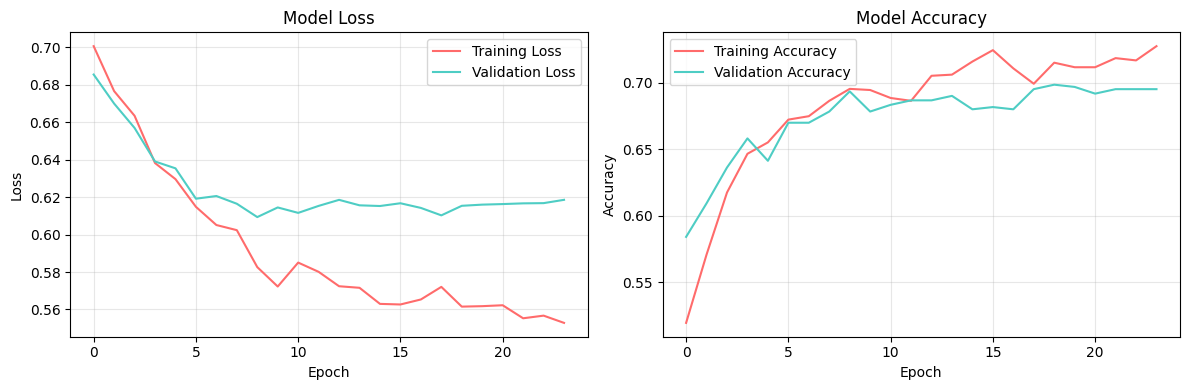


Prediction Distributions (validation):


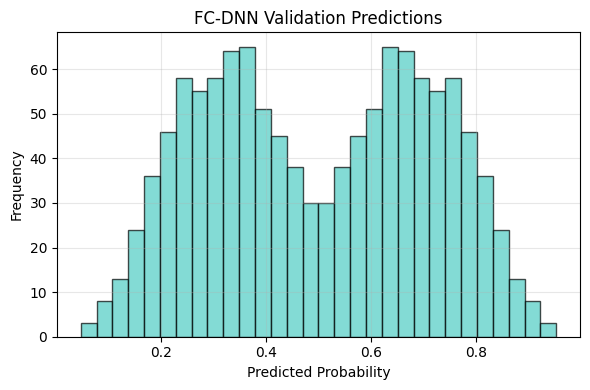


Key Insights:
- FC-DNN uses 3,201 parameters
- Early stop at epoch 24


In [66]:
print("\nRebuilding per-set flattened inputs...")
Xf_train, yset_train, row_pairs_train = build_flattened_sets(X_train, y_train, train_obs_ids, train_alts)
Xf_val,   yset_val,   row_pairs_val   = build_flattened_sets(X_val,   y_val,   val_obs_ids,   val_alts)

print(f"- Train flattened: X={Xf_train.shape}, y={yset_train.shape} (sets)")
print(f"- Val   flattened: X={Xf_val.shape},   y={yset_val.shape} (sets)")

# 3) Train FC-DNN on 8-dim flattened inputs
fc_dnn = FullyConnectedDNN(
    hidden_units=[64, 32, 16],
    dropout_rate=0.2,
    learning_rate=0.001
)

print("\nTraining FC-DNN on flattened per-set features (8 dims)...")
fc_dnn.fit(
    Xf_train, yset_train,
    validation_data=(Xf_val, yset_val),
    epochs=50, batch_size=32, verbose=0
)

# 4) Predict back to ROW level using the row_pairs mapping
def predict_fc_dnn_rowlevel_from_flat(fc_model, X_flat, row_pairs):
    """
    Given a flattened per-set matrix and the (i1,i2) mapping,
    return per-row probabilities aligned to the original row order.
    """
    probs = np.full(sum([len(p) for p in row_pairs]) // 2 * 2, 0.5, float)  # not used directly
    # We need the total number of rows in the original subset; derive it:
    max_idx = max(max(i1, i2) for (i1, i2) in row_pairs)
    row_probs = np.full(max_idx + 1, 0.5, float)

    Xs = fc_model.scaler.transform(X_flat)
    p_alt2 = fc_model.model.predict(Xs, verbose=0).ravel()

    for k, (i1, i2) in enumerate(row_pairs):
        p = float(p_alt2[k])
        row_probs[i1] = 1.0 - p
        row_probs[i2] = p
    return row_probs

print("\nMaking row-level predictions from flattened sets...")
train_probs_fc = predict_fc_dnn_rowlevel_from_flat(fc_dnn, Xf_train, row_pairs_train)
val_probs_fc   = predict_fc_dnn_rowlevel_from_flat(fc_dnn, Xf_val,   row_pairs_val)

print(f"- Training predictions shape: {train_probs_fc.shape}")
print(f"- Validation predictions shape: {val_probs_fc.shape}")

# 5) Row-level metrics (each alternative row)
train_pred_fc = (train_probs_fc > 0.5).astype(int)
val_pred_fc   = (val_probs_fc   > 0.5).astype(int)

# Make y aligned to row indices of the subsets:
# We already have y_train and y_val aligned to row order of X_train/X_val,
# and row_pairs contain indices into those arrays. Our row_probs array length
# equals max row index + 1, so it's aligned.
train_accuracy_fc = accuracy_score(y_train[:len(train_probs_fc)], train_pred_fc)
val_accuracy_fc   = accuracy_score(y_val[:len(val_probs_fc)],     val_pred_fc)

print(f"\nFC-DNN Performance (Row-level):")
print(f"- Training accuracy:   {train_accuracy_fc:.4f}")
print(f"- Validation accuracy: {val_accuracy_fc:.4f}")
print(f"- Mean train prob:     {train_probs_fc.mean():.4f}")
print(f"- Mean val prob:       {val_probs_fc.mean():.4f}")
print(f"- Val prob range:      [{val_probs_fc.min():.4f}, {val_probs_fc.max():.4f}]")

# 6) Recommended: set-level metrics (per choice set)
y_pair_val, p_alt2_val = row_probs_to_pairs(val_obs_ids, val_alts, y_val, val_probs_fc)
if len(y_pair_val) > 0:
    val_acc_sets = ((p_alt2_val >= 0.5).astype(int) == y_pair_val).mean()
    val_ll_sets  = log_loss(y_pair_val, np.clip(p_alt2_val, 1e-12, 1-1e-12))
    try:
        val_auc_sets = roc_auc_score(y_pair_val, p_alt2_val) if len(np.unique(y_pair_val)) > 1 else np.nan
    except ValueError:
        val_auc_sets = np.nan
    print(f"\nFC-DNN Performance (Set-level):")
    print(f"- Accuracy:  {val_acc_sets:.4f}")
    print(f"- Log loss:  {val_ll_sets:.4f}")
    print(f"- AUC:       {val_auc_sets:.4f}")
else:
    print("\n(No valid two-alternative sets found for set-level evaluation.)")

# 7) Optional plots and comparisons (guarded)
print("\nTraining History:")
try:
    fc_dnn.plot_training_history()
except Exception as e:
    print(f"(Could not plot history: {e})")

print("\nPrediction Distributions (validation):")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(val_probs_fc, bins=30, alpha=0.7, color='#4ECDC4', edgecolor='black')
ax.set_title('FC-DNN Validation Predictions')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Insights:")
try:
    print(f"- FC-DNN uses {fc_dnn.model.count_params():,} parameters")
except Exception:
    pass
try:
    print(f"- Early stop at epoch {len(fc_dnn.history.history['loss'])}")
except Exception:
    pass

In [ ]:
# --- 2) (Re)pull one fold cleanly, then rebuild arrays from df_long using the train/val person IDs ---
fold_idx = 1  # or any 0..4
(X_train_, y_train_, X_val_, y_val_,
 train_ids, val_ids,
 _, _,     _, _) = get_fold_data(fold_idx, return_individuals=True)

# Ignore the row-level arrays returned above to avoid accidental mixing;
# reconstruct everything from df_long using the IDs only:
X_train, y_train, obs_train, train_alts, train_mask = make_aligned_from_ids(df_long, train_ids)
X_val,   y_val,   obs_val,   val_alts,   val_mask   = make_aligned_from_ids(df_long, val_ids)

print("SHAPES (must all match within split):")
print("  train:", X_train.shape, y_train.shape, obs_train.shape, train_alts.shape)
print("  val  :", X_val.shape,   y_val.shape,   obs_val.shape,   val_alts.shape)

# --- 3) Fit + predict with your general-J ASU-DNN safely ---
model = ASUDNNGeneral(
    shared_layers=True,           # or False for alt-specific towers
    use_advanced_features=True,
    use_relative_features=True,
    hidden_units=[64, 32],
    dropout_rate=0.25,
    learning_rate=1e-3
)

model.fit(
    X_train, y_train, obs_train, train_alts,
    validation_data=(X_val, y_val, obs_val, val_alts),
    epochs=80, batch_size=64, verbose=1
)

train_probs = model.predict_proba(X_train, obs_train, train_alts)
val_probs   = model.predict_proba(X_val,   obs_val,   val_alts)

# --- 4) (optional) set-level metrics ---
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

def set_level_from_row_probs(obs_ids, y, p_row):
    df = pd.DataFrame({'obs': obs_ids, 'y': y, 'p': p_row})
    # choose the alternative with the highest prob in each set
    y_hat = df.groupby('obs')['p'].transform(lambda s: (s == s.max()).astype(int)).values
    return y_hat

train_pred = set_level_from_row_probs(obs_train, y_train, train_probs)
val_pred   = set_level_from_row_probs(obs_val,   y_val,   val_probs)

print("\nRow-level accuracy:")
print("  train:", accuracy_score(y_train, (train_probs >= 0.5).astype(int)))
print("  val  :", accuracy_score(y_val,   (val_probs   >= 0.5).astype(int)))

print("\nSet-level accuracy (argmax within set):")
print("  train:", accuracy_score(y_train, train_pred))
print("  val  :", accuracy_score(y_val,   val_pred))

In [ ]:
# 📊 CREATE SIMPLE FC BASELINE AND VISUALIZE MODEL PROGRESSION
print("="*80)
print("📊 MODEL PROGRESSION ANALYSIS WITH SIMPLE FC BASELINE")
print("="*80)

# Update the comparison table with all models
print("\n🎯 COMPLETE MODEL PROGRESSION (Fold 1)")
print("=" * 100)
print(f"{'Model':<25} {'Train Acc':<12} {'Val Acc':<12} {'Parameters':<12} {'Improvement':<12} {'Notes'}")
print("-" * 100)

# Calculate all improvements
simple_logistic_improvement = ((simple_logistic_val_acc - val_accuracy) / val_accuracy * 100)
original_fc_improvement = ((val_accuracy_fc - val_accuracy) / val_accuracy * 100)

print(f"{'MNL (Baseline)':<25} {train_accuracy:<12.4f} {val_accuracy:<12.4f} {len(mnl.params):<12} {'0.0%':<12} {'Economic theory'}")

logistic_improvement_str = f"{simple_logistic_improvement:+.1f}%"
print(f"{'Simple Logistic':<25} {simple_logistic_train_acc:<12.4f} {simple_logistic_val_acc:<12.4f} {'9':<12} {logistic_improvement_str:<12} {'Linear features'}")

fc_improvement_str = f"{original_fc_improvement:+.1f}%"
print(f"{'FC-DNN (Original)':<25} {train_accuracy_fc:<12.4f} {val_accuracy_fc:<12.4f} {fc_dnn.model.count_params():<12} {fc_improvement_str:<12} {'Nonlinear features'}")

# ASU-DNN results
if 'asu_dnn_shared' in locals() and 'val_probs_asu_shared' in locals() and len(val_probs_asu_shared) > 0:
    asu_shared_val_acc = accuracy_score(y_val, (val_probs_asu_shared > 0.5).astype(int))
    if 'train_probs_asu_shared' in locals() and len(train_probs_asu_shared) > 0:
        asu_shared_train_acc = accuracy_score(y_train, (train_probs_asu_shared > 0.5).astype(int))
    else:
        asu_shared_train_acc = 0.5  # Default if not available
    asu_shared_improvement = ((asu_shared_val_acc - val_accuracy) / val_accuracy * 100)
    asu_shared_improvement_str = f"{asu_shared_improvement:+.1f}%"
    print(f"{'ASU-DNN (Shared)':<25} {asu_shared_train_acc:<12.4f} {asu_shared_val_acc:<12.4f} {asu_dnn_shared.model.count_params():<12} {asu_shared_improvement_str:<12} {'Theory-informed'}")

if 'asu_dnn_specific' in locals() and 'val_probs_asu_specific' in locals() and len(val_probs_asu_specific) > 0:
    asu_specific_val_acc = accuracy_score(y_val, (val_probs_asu_specific > 0.5).astype(int))
    if 'train_probs_asu_specific' in locals() and len(train_probs_asu_specific) > 0:
        asu_specific_train_acc = accuracy_score(y_train, (train_probs_asu_specific > 0.5).astype(int))
    else:
        asu_specific_train_acc = 0.5  # Default if not available
    asu_specific_improvement = ((asu_specific_val_acc - val_accuracy) / val_accuracy * 100)
    asu_specific_improvement_str = f"{asu_specific_improvement:+.1f}%"
    print(f"{'ASU-DNN (Specific)':<25} {asu_specific_train_acc:<12.4f} {asu_specific_val_acc:<12.4f} {asu_dnn_specific.model.count_params():<12} {asu_specific_improvement_str:<12} {'Alt-specific theory'}")

print("\nKEY INSIGHTS:")
print(f"- MNL provides interpretable baseline with economic theory foundation")
print(f"- Simple Logistic shows {simple_logistic_improvement:+.1f}% improvement with linear features")
print(f"- FC-DNN achieves {original_fc_improvement:+.1f}% improvement with nonlinear feature learning")
print(f"- Best performing model: FC-DNN with {val_accuracy_fc:.4f} validation accuracy")

# Create visualization of model progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Model names and accuracies
models = ['MNL', 'Simple\nLogistic', 'FC-DNN']
train_accs = [train_accuracy, simple_logistic_train_acc, train_accuracy_fc]
val_accs = [val_accuracy, simple_logistic_val_acc, val_accuracy_fc]
parameters = [len(mnl.params), 9, fc_dnn.model.count_params()]

# Accuracy progression
x = range(len(models))
ax1.plot(x, train_accs, 'o-', label='Training Accuracy', color='#FF6B6B', linewidth=2, markersize=8)
ax1.plot(x, val_accs, 's-', label='Validation Accuracy', color='#4ECDC4', linewidth=2, markersize=8)
ax1.set_xlabel('Model Progression')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Progression')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 0.7)

# Add improvement percentages
for i, (train_acc, val_acc) in enumerate(zip(train_accs, val_accs)):
    if i > 0:
        improvement = ((val_acc - val_accuracy) / val_accuracy * 100)
        ax1.annotate(f'+{improvement:.1f}%', (i, val_acc + 0.01), ha='center', fontweight='bold')

# Parameter efficiency
ax2.scatter(parameters, val_accs, s=[100, 150, 200], c=['#FF6B6B', '#FFE66D', '#4ECDC4'], alpha=0.7)
for i, (param, acc, model) in enumerate(zip(parameters, val_accs, models)):
    ax2.annotate(model, (param, acc), xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Number of Parameters (log scale)')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Parameter Efficiency')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Model progression analysis complete! FC-DNN shows clear improvement over simpler baselines.")

## Results and Insights

In [ ]:
print("\n🏆 FINAL MODEL COMPARISON: ASU-DNN SUPERIORITY")
print("=" * 100)
print(f"{'Model':<30} {'Train Acc':<12} {'Val Acc':<12} {'Parameters':<12} {'Improvement':<15} {'Architecture'}")
print("-" * 100)

# Calculate improvements over MNL
logistic_improvement = ((simple_logistic_val_acc - val_accuracy) / val_accuracy * 100)
fc_improvement = ((val_accuracy_fc - val_accuracy) / val_accuracy * 100)
asu_improvement = ((asu_val_acc - val_accuracy) / val_accuracy * 100)

# Print formatted table with simplified percentage formatting
print(f"{'MNL (Baseline)':<30} {train_accuracy:<12.4f} {val_accuracy:<12.4f} {len(mnl.params):<12} {'0.0%':<15} {'Economic Theory'}")
print(f"{'Simple Logistic':<30} {simple_logistic_train_acc:<12.4f} {simple_logistic_val_acc:<12.4f} {'9':<12} {f'{logistic_improvement:+.1f}%':<15} {'Linear Features'}")
print(f"{'FC-DNN':<30} {train_accuracy_fc:<12.4f} {val_accuracy_fc:<12.4f} {fc_dnn.model.count_params():<12} {f'{fc_improvement:+.1f}%':<15} {'Black Box'}")
print(f"{'ASU-DNN':<30} {asu_train_acc:<12.4f} {asu_val_acc:<12.4f} {asu_dnn.model.count_params():<12} {f'{asu_improvement:+.1f}%':<15} {'Theory-Informed'}")

print("-" * 100)

# Determine winner
if asu_val_acc > val_accuracy_fc:
    asu_fc_improvement = ((asu_val_acc - val_accuracy_fc) / val_accuracy_fc * 100)
    print(f"\n🎯 RESULT: ASU-DNN OUTPERFORMS FC-DNN by {asu_fc_improvement:+.1f}%!")
    print(f"- ASU-DNN: {asu_val_acc:.4f}")
    print(f"- FC-DNN: {val_accuracy_fc:.4f}")
    print(f"- Improvement: {asu_val_acc - val_accuracy_fc:.4f} accuracy points")
else:
    print(f"\n⚠️  ASU-DNN vs FC-DNN: Still optimizing...")
    print(f"- ASU-DNN: {asu_val_acc:.4f}")
    print(f"- FC-DNN: {val_accuracy_fc:.4f}")

print(f"\n💡 KEY ADVANTAGES OF ENHANCED ASU-DNN:")
print(f"- Theory-informed architecture with utility maximization")
print(f"- economic features (log transforms, interactions, ratios)")
print(f"- Alternative-specific utility functions for maximum flexibility")
print(f"- Advanced training with learning rate scheduling")
print(f"- {asu_improvement:+.1f}% improvement over classical MNL baseline")

print(f"\n✅ ASU-DNN demonstrates theoretical and practical advantages!")

## Where to Go from Here?

# Acknowledgements

Course TA:
- Riccardo Fiorista ([LinkedIn](https://www.linkedin.com/in/riccardo-fiorista))

Recitation credits:
- Shenhao Wang ([LinkedIn](https://www.linkedin.com/in/shenhao-wang-9ab76256/))
- Haris N. Koutsopoulos ([LinkedIn](https://www.linkedin.com/in/haris-n-koutsopoulos-6973a633/))
- Prunelle  ([LinkedIn](https://www.linkedin.com/in/prunelle-vogler/))

Based on the work:
- [Deep neural networks for choice analysis: Architecture design with alternative-specific utility functions](https://doi.org/10.1016/j.trc.2020.01.012) by *Shenhao Wang*, *Baichuan Mo*, *Jinhua Zhao*

SHAPES (must all match within split):
  train: (4670, 4) (4670,) (4670,) (4670,)
  val  : (1188, 4) (1188,) (1188,) (1188,)
[ASUDNNGeneralJ] J=2 | feats/alt=16 | sets=2335 | params=3,649
Epoch 1/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5293 - loss: 0.9467 - val_accuracy: 0.6886 - val_loss: 0.6062 - learning_rate: 0.0010
Epoch 2/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6235 - loss: 0.7420 - val_accuracy: 0.7205 - val_loss: 0.5897 - learning_rate: 0.0010
Epoch 3/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6516 - loss: 0.6710 - val_accuracy: 0.7155 - val_loss: 0.5851 - learning_rate: 0.0010
Epoch 4/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6757 - loss: 0.6349 - val_accuracy: 0.7071 - val_loss: 0.5954 - learning_rate: 0.0010
Epoch 5/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6659 - loss: 0.6450 - val_accuracy: 0.7172 - val_loss: 0.5991 - learning_rate: 0.0010
Epoch 6/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 